In [136]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Missing Value Profiling and Handling Strategy

In [104]:
df = pd.read_csv(filepath_or_buffer="netflix_titles.csv")

In [105]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [107]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

I do not think there is a need to drop those rows where there are some `NaN` values. Better is to fill them with boilerplate `unrecorder` value - we already are short of data, dropping them will cause distorted analysis.

In [108]:
df = df.fillna(value="unrecorded")

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


### 2. Duration Parsing and Standardization

In [110]:
df["type"].unique()

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [111]:
df["duration_minutes"] = (
    df["duration"]
    .where(df["duration"].str.contains("min", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

df["duration_seasons"] = (
    df["duration"]
    .where(df["duration"].str.lower().str.contains("season", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

In [112]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unrecorded,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,TV Show,Blood & Water,unrecorded,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unrecorded,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,unrecorded,unrecorded,unrecorded,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,TV Show,Kota Factory,unrecorded,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0


### 3. Temporal Format Standardization

In [113]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    format="%B %d, %Y",
    errors="coerce",
)

In [114]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [115]:
(df["date_added"].dtype)

dtype('<M8[us]')

In [116]:
df["date_added"].isnull().sum()

np.int64(10)

In [117]:
df["date_added_year"] = df["date_added"].dt.year
df["date_added_month"] = df["date_added"].dt.month
df["date_added_day"] = df["date_added"].dt.day

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          8807 non-null   str           
 4   cast              8807 non-null   str           
 5   country           8807 non-null   str           
 6   date_added        8797 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   str           
 9   duration          8807 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  duration_minutes  6128 non-null   float64       
 13  duration_seasons  2676 non-null   float64       
 14  date_added_year   8797 non-null   f

### 4. Format Strategy Over Time

In [119]:
year_type_titles = (
    df.groupby(by=["release_year", "type"])
    .agg(titles=("show_id", "count"))
    .sort_values(by="release_year")
    .reset_index()
)

In [120]:
year_type_titles.head()

,release_year,type,titles
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


In [121]:
pivot_data = (
    year_type_titles.pivot(
        index="release_year",
        columns="type",
        values="titles",
    )
    .fillna(0)
    .sort_index()
)


In [122]:
pivot_data.head()

type,Movie,TV Show
release_year,,
1925,0.0,1.0
1942,2.0,0.0
1943,3.0,0.0
1944,3.0,0.0
1945,3.0,1.0


In [123]:
# if "Movie" not in pivot_data.columns:
# checks if the column named "Movie" exists in the pivoted DataFrame.
# pivot_data["Movie"] = 0 initializes a new column named "Movie"
# populated entirely with zeros if it was missing.
# The same logic is applied to "TV Show".

if "Movie" not in pivot_data.columns:
    pivot_data["Movie"] = 0
if "TV Show" not in pivot_data.columns:
    pivot_data["TV Show"] = 0

In [124]:
pivot_data["Total"] = pivot_data["Movie"] + pivot_data["TV Show"]
pivot_data["Movie_Pct"] = (
    pivot_data["Movie"] / pivot_data["Total"].replace(0, 1)
) * 100
pivot_data["TV_Pct"] = (
    pivot_data["TV Show"] / pivot_data["Total"].replace(0, 1)
) * 100

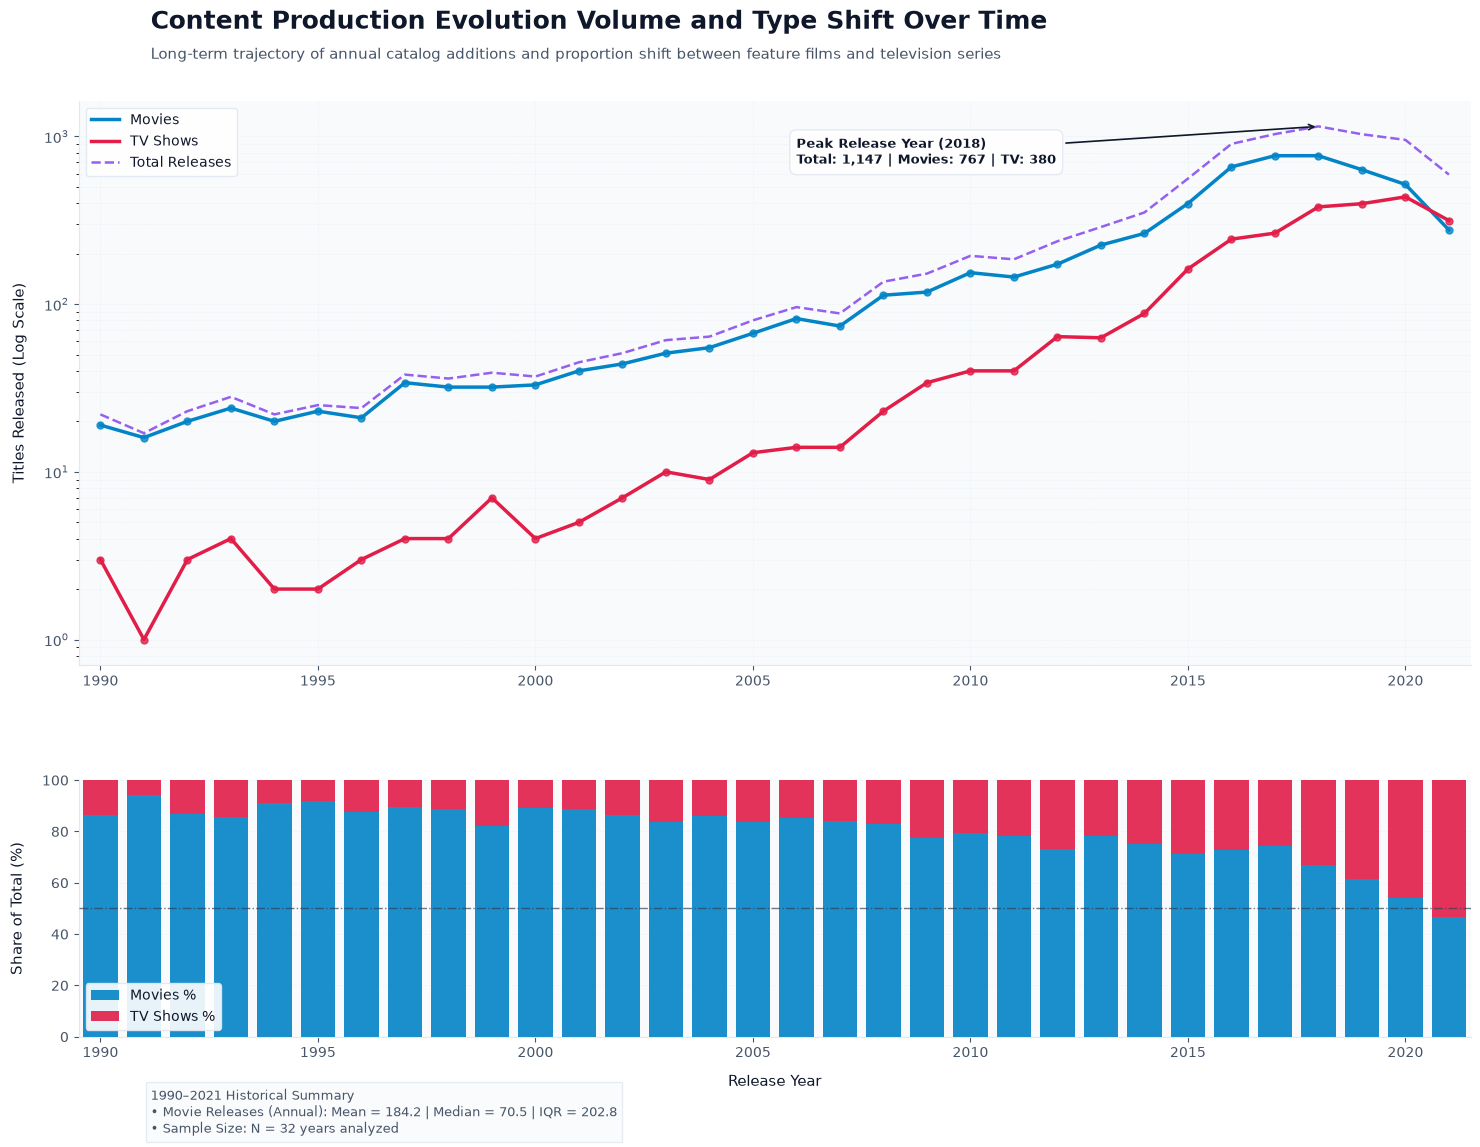

In [125]:
all_years = np.arange(pivot_data.index.min(), pivot_data.index.max() + 1)
pivot_data = pivot_data.reindex(all_years, fill_value=0)

recent_data = pivot_data.loc[pivot_data.index >= 1990]

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
MOVIE_COLOR = "#0284C7"
TV_COLOR = "#E11D48"
GRID_COLOR = "#E2E8F0"

title_text = "Content Production Evolution Volume and Type Shift Over Time"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1], hspace=0.28)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

years = recent_data.index.values
movies = recent_data["Movie"].values
tv_shows = recent_data["TV Show"].values
totals = recent_data["Total"].values

ax0.plot(
    years, movies, color=MOVIE_COLOR, linewidth=2.5, label="Movies", zorder=4
)
ax0.scatter(years, movies, color=MOVIE_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years, tv_shows, color=TV_COLOR, linewidth=2.5, label="TV Shows", zorder=4
)
ax0.scatter(years, tv_shows, color=TV_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years,
    totals,
    color="#7C3AED",
    linewidth=1.8,
    linestyle="--",
    label="Total Releases",
    alpha=0.8,
    zorder=3,
)

ax0.set_yscale("log")
ax0.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)
ax0.set_ylabel(
    "Titles Released (Log Scale)", color=TEXT_COLOR, fontsize=11, labelpad=12
)

max_year = recent_data["Total"].idxmax()
max_total = recent_data.loc[max_year, "Total"]
max_movie = recent_data.loc[max_year, "Movie"]
max_tv = recent_data.loc[max_year, "TV Show"]

ax0.annotate(
    f"Peak Release Year ({max_year})\nTotal: {int(max_total):,} | Movies: {int(max_movie):,} | TV: {int(max_tv):,}",
    xy=(max_year, max_total),
    xytext=(max_year - 12, max_total * 0.6),
    arrowprops={"arrowstyle": "->", "color": TEXT_COLOR, "lw": 1.2},
    color=TEXT_COLOR,
    fontsize=9.5,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

movie_pcts = recent_data["Movie_Pct"].values
tv_pcts = recent_data["TV_Pct"].values

ax1.bar(
    years,
    movie_pcts,
    color=MOVIE_COLOR,
    label="Movies %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)
ax1.bar(
    years,
    tv_pcts,
    bottom=movie_pcts,
    color=TV_COLOR,
    label="TV Shows %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)

ax1.axhline(
    50, color="#334155", linestyle="-.", linewidth=1, alpha=0.7, zorder=4
)
ax1.set_ylabel("Share of Total (%)", color=TEXT_COLOR, fontsize=11, labelpad=12)
ax1.set_ylim(0, 100)
ax1.set_xlabel("Release Year", color=TEXT_COLOR, fontsize=11, labelpad=10)
ax1.grid(
    True,
    which="major",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_xlim(years.min() - 0.5, years.max() + 0.5)

ax0.set_xticks(np.arange(1990, years.max() + 1, 5))
ax1.set_xticks(np.arange(1990, years.max() + 1, 5))

mean_movies = recent_data["Movie"].mean()
median_movies = recent_data["Movie"].median()
iqr_movies = recent_data["Movie"].quantile(0.75) - recent_data[
    "Movie"
].quantile(0.25)

stats_str = (
    f"1990–{years.max()} Historical Summary\n"
    f"• Movie Releases (Annual): Mean = {mean_movies:.1f} | Median = {median_movies:.1f} | IQR = {iqr_movies:.1f}\n"
    f"• Sample Size: N = {len(recent_data)} years analyzed"
)

fig.text(
    0.125, 0.94, title_text, color=TEXT_COLOR, fontsize=18, fontweight="bold"
)
fig.text(
    0.125,
    0.915,
    "Long-term trajectory of annual catalog additions and proportion shift between feature films and television series",
    color=MUTED_TEXT,
    fontsize=11,
)

fig.text(
    0.125,
    0.02,
    stats_str,
    color=MUTED_TEXT,
    fontsize=9,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": PANEL_BG,
        "edgecolor": GRID_COLOR,
        "alpha": 0.8,
    },
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="upper left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="lower left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.08, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path,
    dpi=800,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

### 5. Multi-Valued Geographical Footprint

In [137]:
countries_titles: dict[str, float] = {}

for countries in df["country"]:
    if countries.startswith("unrecorded"):
        continue

    countries_list: list = countries.strip().split(",")
    if len(countries_list) == 1:
        countries_titles[countries_list[0]] = (
            countries_titles.get(countries_list[0], 0) + 1
        )
        continue

    for country in countries_list:
        countries_titles[country] = round(
            countries_titles.get(country, 0) + 1 / len(countries_list), 1
        )

countries_titles = sorted(
    countries_titles.items(), key=lambda item: item[1], reverse=True
)

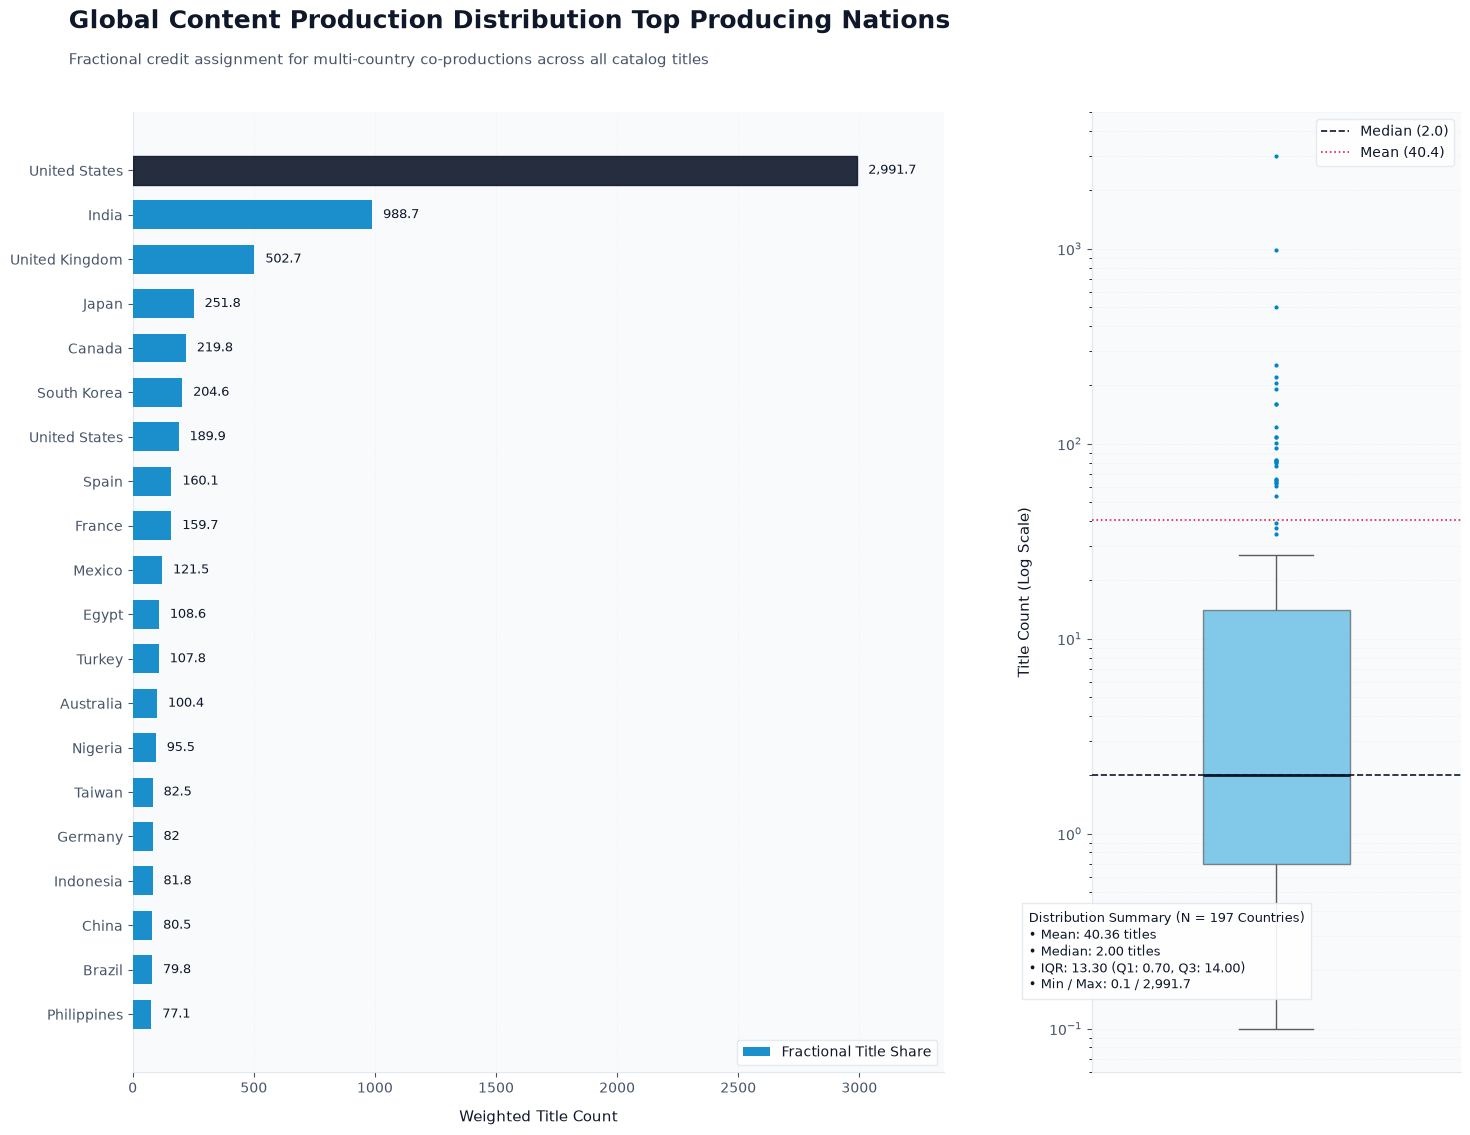

In [139]:
country_df = pd.DataFrame(countries_titles, columns=["Country", "Titles"])
top_20 = country_df.head(20).copy()
top_20 = top_20.iloc[::-1].reset_index(drop=True)

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
PRIMARY_COLOR = "#0284C7"
SECONDARY_COLOR = "#38BDF8"
ACCENT_COLOR = "#0F172A"
GRID_COLOR = "#E2E8F0"

title_text = "Global Content Production Distribution Top Producing Nations"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1], wspace=0.25)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

bars = ax0.barh(
    top_20["Country"],
    top_20["Titles"],
    color=PRIMARY_COLOR,
    height=0.65,
    alpha=0.9,
    zorder=3,
    label="Fractional Title Share",
)

bars[-1].set_color(ACCENT_COLOR)

max_val = top_20["Titles"].max()
for bar, value in zip(bars, top_20["Titles"]):
    ax0.text(
        value + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.1f}" if value % 1 != 0 else f"{int(value):,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax0.set_xlabel(
    "Weighted Title Count", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax0.set_xlim(0, max_val * 1.12)
ax0.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

all_values = country_df["Titles"].values
non_zero_values = all_values[all_values > 0]

sns.boxplot(
    y=non_zero_values,
    ax=ax1,
    color=SECONDARY_COLOR,
    width=0.4,
    fliersize=3,
    flierprops={"markerfacecolor": PRIMARY_COLOR, "markeredgecolor": "none"},
    medianprops={"color": ACCENT_COLOR, "linewidth": 2},
    boxprops={"alpha": 0.7},
    zorder=3,
)

ax1.set_yscale("log")
ax1.set_ylabel(
    "Title Count (Log Scale)", color=TEXT_COLOR, fontsize=11, labelpad=12
)
ax1.set_xticks([])
ax1.grid(
    True,
    which="both",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

mean_val = np.mean(non_zero_values)
median_val = np.median(non_zero_values)
q25 = np.percentile(non_zero_values, 25)
q75 = np.percentile(non_zero_values, 75)
iqr_val = q75 - q25

ax1.axhline(
    median_val,
    color=ACCENT_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"Median ({median_val:.1f})",
    zorder=4,
)
ax1.axhline(
    mean_val,
    color="#E11D48",
    linestyle=":",
    linewidth=1.2,
    label=f"Mean ({mean_val:.1f})",
    zorder=4,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)

stats_str = (
    f"Distribution Summary (N = {len(non_zero_values)} Countries)\n"
    f"• Mean: {mean_val:.2f} titles\n"
    f"• Median: {median_val:.2f} titles\n"
    f"• IQR: {iqr_val:.2f} (Q1: {q25:.2f}, Q3: {q75:.2f})\n"
    f"• Min / Max: {non_zero_values.min():.1f} / {non_zero_values.max():,.1f}"
)

fig.text(
    0.08,
    0.95,
    title_text,
    color=TEXT_COLOR,
    fontsize=18,
    fontweight="bold",
)
fig.text(
    0.08,
    0.92,
    "Fractional credit assignment for multi-country co-productions across all catalog titles",
    color=MUTED_TEXT,
    fontsize=11,
)

fig.text(
    0.68,
    0.15,
    stats_str,
    color=TEXT_COLOR,
    fontsize=9.5,
    bbox={
        "boxstyle": "square,pad=0.5",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="lower right",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="upper right",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.88, bottom=0.08, left=0.12, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 6. Genre Affinity Analysis

In [153]:
movie_comedy: dict = {}
tvshow_kids_tv: dict = {}

for row in df[["type", "listed_in"]].itertuples():
    if not isinstance(row.type, str) or not isinstance(row.listed_in, str):
        continue

    type_, genres = row.type.lower(), row.listed_in

    genres: list = genres.split(", ")

    if type_.startswith("movie") and "Comedies" in genres:
        genres.remove("Comedies")
        for genre in genres:
            movie_comedy[genre] = movie_comedy.get(genre, 0) + 1

    elif type_.startswith("tv show") and "Kids' TV" in genres:
        genres.remove("Kids' TV")
        for genre in genres:
            tvshow_kids_tv[genre] = tvshow_kids_tv.get(genre, 0) + 1


movie_comedy = sorted(
    movie_comedy.items(),
    key=lambda item: item[1],
    reverse=True,
)

tvshow_kids_tv = sorted(
    tvshow_kids_tv.items(),
    key=lambda item: item[1],
    reverse=True,
)

print(movie_comedy)
print(tvshow_kids_tv)


[('International Movies', 804), ('Dramas', 502), ('Romantic Movies', 277), ('Children & Family Movies', 270), ('Independent Movies', 194), ('Action & Adventure', 183), ('Music & Musicals', 91), ('Horror Movies', 40), ('Cult Movies', 38), ('Sci-Fi & Fantasy', 33), ('Classic Movies', 23), ('Sports Movies', 23), ('LGBTQ Movies', 23), ('Thrillers', 8), ('Faith & Spirituality', 8), ('Documentaries', 3)]
[('TV Comedies', 127), ('British TV Shows', 31), ('Anime Series', 24), ('Korean TV Shows', 23), ('TV Action & Adventure', 22), ('TV Sci-Fi & Fantasy', 14), ('TV Dramas', 13), ('TV Thrillers', 6), ('Spanish-Language TV Shows', 6), ('Teen TV Shows', 4), ('Classic & Cult TV', 4), ('Crime TV Shows', 3), ('Reality TV', 2), ('Science & Nature TV', 2), ('International TV Shows', 1), ('TV Mysteries', 1), ('Docuseries', 1)]


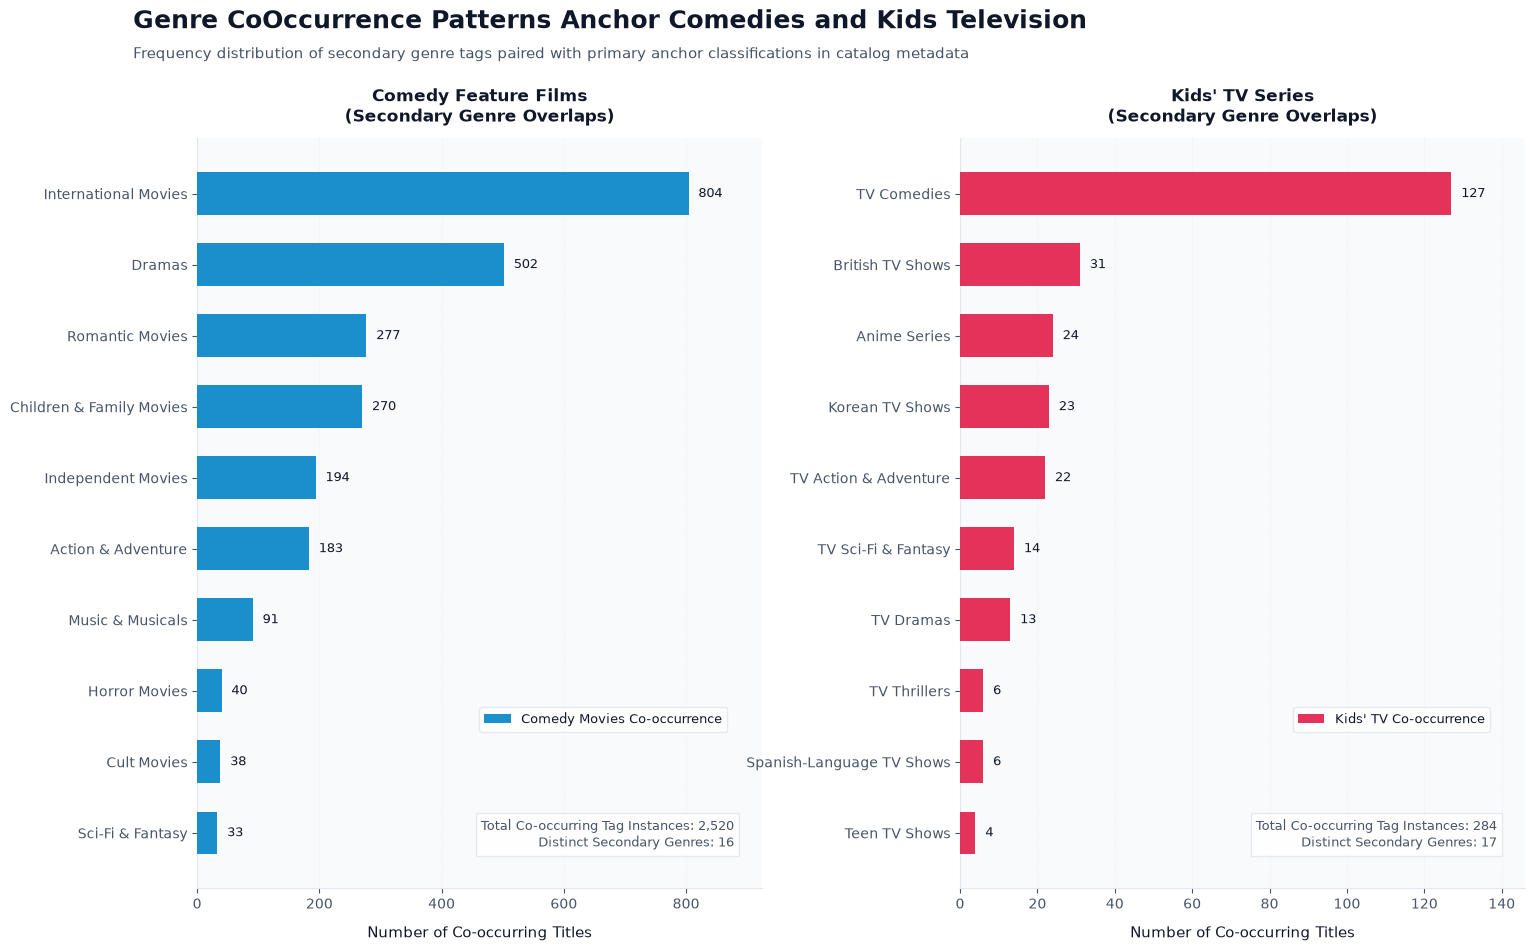

In [155]:
movie_df = pd.DataFrame(
    movie_comedy,
    columns=["Genre", "Count"],
)
tv_df = pd.DataFrame(
    tvshow_kids_tv,
    columns=["Genre", "Count"],
)

movie_top = movie_df.head(10).iloc[::-1].reset_index(drop=True)
tv_top = tv_df.head(10).iloc[::-1].reset_index(drop=True)

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
MOVIE_COLOR = "#0284C7"
TV_COLOR = "#E11D48"
GRID_COLOR = "#E2E8F0"

title_text = "Genre CoOccurrence Patterns Anchor Comedies and Kids Television"

fig = plt.figure(figsize=(16, 10), facecolor=BG_COLOR)
gs = fig.add_gridspec(1, 2, wspace=0.35)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

bars0 = ax0.barh(
    movie_top["Genre"],
    movie_top["Count"],
    color=MOVIE_COLOR,
    height=0.6,
    alpha=0.9,
    zorder=3,
    label="Comedy Movies Co-occurrence",
)

max_movie_val = movie_top["Count"].max() if not movie_top.empty else 1
for bar, val in zip(bars0, movie_top["Count"]):
    ax0.text(
        val + (max_movie_val * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax0.set_xlabel(
    "Number of Co-occurring Titles", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax0.set_title(
    "Comedy Feature Films\n(Secondary Genre Overlaps)",
    color=TEXT_COLOR,
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax0.set_xlim(0, max_movie_val * 1.15)
ax0.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

bars1 = ax1.barh(
    tv_top["Genre"],
    tv_top["Count"],
    color=TV_COLOR,
    height=0.6,
    alpha=0.9,
    zorder=3,
    label="Kids' TV Co-occurrence",
)

max_tv_val = tv_top["Count"].max() if not tv_top.empty else 1
for bar, val in zip(bars1, tv_top["Count"]):
    ax1.text(
        val + (max_tv_val * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax1.set_xlabel(
    "Number of Co-occurring Titles", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax1.set_title(
    "Kids' TV Series\n(Secondary Genre Overlaps)",
    color=TEXT_COLOR,
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xlim(0, max_tv_val * 1.15)
ax1.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)

movie_total_co = movie_df["Count"].sum()
tv_total_co = tv_df["Count"].sum()

stats_str0 = f"Total Co-occurring Tag Instances: {movie_total_co:,}\nDistinct Secondary Genres: {len(movie_df)}"
stats_str1 = f"Total Co-occurring Tag Instances: {tv_total_co:,}\nDistinct Secondary Genres: {len(tv_df)}"

ax0.text(
    0.95,
    0.05,
    stats_str0,
    transform=ax0.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=MUTED_TEXT,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

ax1.text(
    0.95,
    0.05,
    stats_str1,
    transform=ax1.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=MUTED_TEXT,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

fig.text(
    0.08, 0.96, title_text, color=TEXT_COLOR, fontsize=18, fontweight="bold"
)
fig.text(
    0.08,
    0.93,
    "Frequency distribution of secondary genre tags paired with primary anchor classifications in catalog metadata",
    color=MUTED_TEXT,
    fontsize=11,
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.2),
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=9.5,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.2),
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=9.5,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.85, bottom=0.1, left=0.12, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)
